In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import pyproj as proj

from flux_footprint.utils import find_transform, mask_fp_cutoff
from flux_footprint import calc_footprint_FFP as fp_1
from flux_footprint import calc_footprint_FFP_climatology as fp_2
print("Kljun FFP model imported successfully!")

Kljun FFP model imported successfully!


In [2]:
# measurement height above displacement height [m].
zm = 52.12
# canopy height [m].
hc = 10
# roughness length [m], enter [None] if not known.
z0 = hc*0.15
# mean wind speed at zm [m/s], enter [None] if not known.
umean = 12.27
# boundary layer height [m].
h = 3000
# Obukhov length [m].
ol = -5
# standard deviation of lateral velocity fluctuations [m/s].
sigmav = 4.4
# fricition velocity [m/s].
ustar = 1.93
# wind direction in degrees (of 360 for rotation of the footprint).
wind_dir = 120
# domain size as an array of [xmin xmax ymin ymax] [m].
domain = None
# cell size of domain [m]. default is dx=dy=2 m.
dx, dy = 3, 3
# two integer scalars defining the number of grid elements in x and y. if dx, dy and nx, ny are given, dx, dy is given priority
nx, ny = 200, 200
# percentage of source area for which to provide contours, must be between 10% and 90%.
rs = 0.9
# crop output area to size of the 80% footprint or the largest r given if crop = 1.
crop = 0
# fig = 1 with figure, and fig = 0 with no figure.
fig = 1

# information about the eddy covariance flux tower
# site latitude
latitude = 37.0334
# site longitude
longitude = -119.2622
# cutoff value between 0 and 1 
cutoff = 0.9

# output raster data as tif format
filename = "US-xSP_footprint_test_delete.tif"


Alert(0013):
 Using z0, ignoring umean if passed.


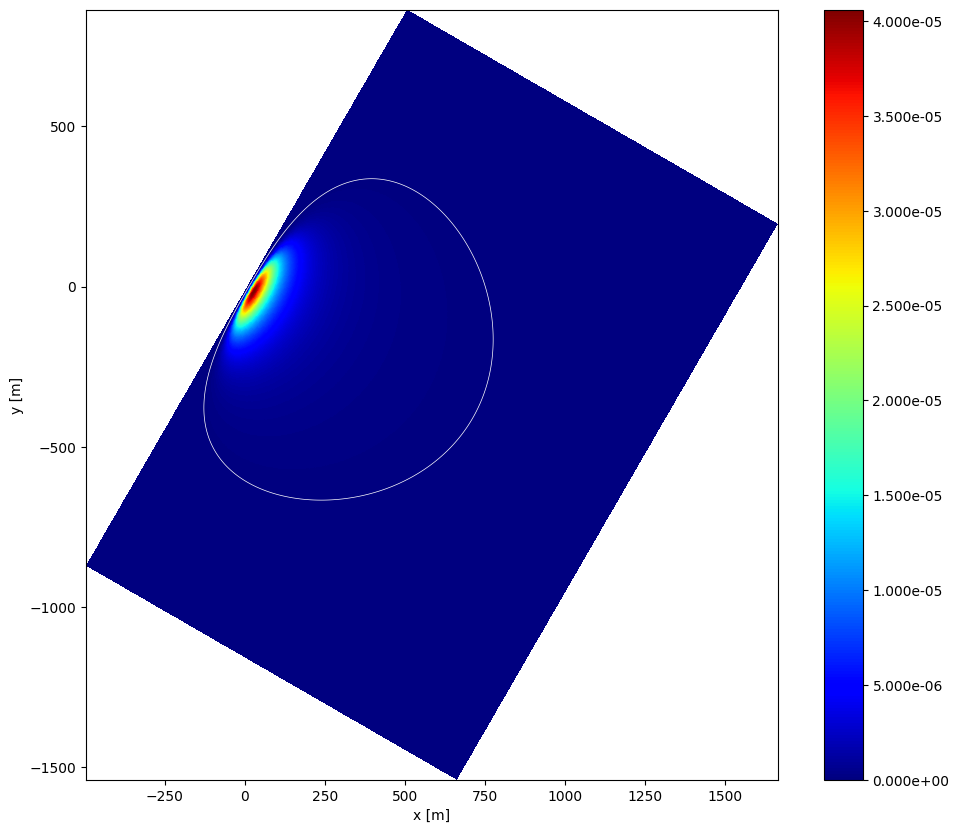


Alert(0017):
 Only one value of zm passed. Using it for all footprints.
 Execution continues.

Alert(0013):
 Using z0, ignoring umean if passed.
 Execution continues.

Calculating footprint  1  of  1


In [3]:
FFP_1 = fp_1.FFP(zm=zm,
                 z0=z0,
                 umean=umean,
                 h=h,
                 ol=ol,
                 sigmav=sigmav,
                 ustar=ustar,
                 wind_dir=wind_dir,
                 rs=rs,
                 crop=crop,
                 fig=1)
FFP_2 = fp_2.FFP_climatology(zm=zm,
                             z0=z0,
                             umean=umean,
                             h=h,
                             ol=ol,
                             sigmav=sigmav,
                             ustar=ustar,
                             wind_dir=wind_dir,
                             dx=dx,
                             dy=dy,
                             rs=rs,
                             crop=crop,
                             fig=0)

## Footprint area exporting as tiff format

In [ ]:
# convert locations into UTM Zone 10N.
cor_x = round(longitude,4)
cor_y = round(latitude,4)
site_cord = (cor_x,cor_y) 
# WGS 84 Geographic Coordinate System
prj_gcs = proj.Proj(init='EPSG:4326')
# WGS 84 / UTM Zone 10N Projected Coordinate System
prj_pcs = proj.Proj(init='EPSG:32610')
(site_x,site_y) = proj.transform(prj_gcs,prj_pcs,*site_cord)

output_data = None
f_2d = np.array(FFP_2['fclim_2d'])
x_2d = np.array(FFP_2['x_2d']) + site_x
y_2d = np.array(FFP_2['y_2d']) + site_y
f_2d = f_2d*dx**2

#Calculate affine transform for given x_2d and y_2d
affine_transform = find_transform(x_2d,y_2d)

new_dat = rasterio.open(filename,'w',driver='GTiff',dtype=rasterio.float64,
                        count=1,height=f_2d.shape[0],width=f_2d.shape[1],
                        transform=affine_transform,
                        crs='+proj=utm +zone=10 +ellps=WGS84 +datum=WGS84 +units=m +no_defs',
                        nodata=0.00000000e+000)
# #Mask out points that are below a % threshold (defaults to 90%)
f_2d = mask_fp_cutoff(f_2d, cutoff=cutoff)
#Write the new band
new_dat.write(f_2d,1)
new_dat.close()
new_dat = None

c:\tools\Anaconda\envs\test_footprint_delete\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\tools\Anaconda\envs\test_footprint_delete\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\Raymond G\AppData\Local\Temp\ipykernel_50444\2465627457.py:13: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrad